# NLP 情感分析 - 多模型对比实验

本笔记本对比不同机器学习模型在中文情感分析任务上的性能表现。

## 实验目标
- 比较多种分类模型的准确率
- 分析模型训练时间
- 找出最优的模型配置
- 为生产环境提供模型选择建议

## 对比模型
1. **逻辑回归 (Logistic Regression)** - 基础模型
2. **K-最近邻 (KNN)**
3. **随机森林 (Random Forest)**
4. **决策树 (Decision Tree)**
5. **朴素贝叶斯 (Naive Bayes)**
6. **支持向量机 (SVM)**

---

In [4]:
# 导入必要的库
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import pickle
import time
import warnings
from collections import defaultdict

# 添加项目根目录到Python路径
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# 导入项目模块
from src.data.cleaner import DataCleaner
from src.data.processor import DataProcessor
from src.features.extractor import FeatureExtractor
from src.models.trainer import ModelTrainer
from src.utils.config import FileConfig

# 导入机器学习模型
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

# 设置绘图风格
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 关闭警告
warnings.filterwarnings('ignore')

print("✅ 所有库导入成功")

d:\Anaconda3\envs\nlp\lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


✅ 所有库导入成功


In [5]:
# 1. 加载数据
print("📂 加载数据集...")
df = pd.read_csv('../data/processed/sentiment_dataset.csv')
print(f"✅ 数据加载完成，形状: {df.shape}")
print(f"\n数据集信息:")
print(f"  - 总样本数: {len(df)}")
print(f"  - 正面样本: {len(df[df['label']==1])} ({len(df[df['label']==1])/len(df)*100:.1f}%)")
print(f"  - 负面样本: {len(df[df['label']==0])} ({len(df[df['label']==0])/len(df)*100:.1f}%)")
print(f"\n前5条样本:")
print(df.head())

📂 加载数据集...
✅ 数据加载完成，形状: (7831, 2)

数据集信息:
  - 总样本数: 7831
  - 正面样本: 5070 (64.7%)
  - 负面样本: 2761 (35.3%)

前5条样本:
                                                text  label
0  ﻿ 真机 很漂亮 体验 看 评论 说 发烫 情况 几天 摄像头 有点 现在 挺 待机 感觉 ...      1
1  外观 好看 黄色 特别 喜欢 裸机 非常 好看 旁边 黑边 略微 习惯 还好 面部 解锁 非...      1
2  手感 光滑 圆润 质感 不像 中 略厚 一点点 适合 女孩子 无碍 诟病 屏幕 黑边 我觉 ...      1
3  这次 iphone11 值得 购买 拍摄 方面 很大 提升 夜景 模式 测试 看 原图 噪点...      1
4  手机 不错 毕竟 系统 强大 拍照 效果 音效 都 提升 操作 顺滑 待机 期间 长刚 激活...      1


In [6]:
# 2. 数据预处理和划分
print("\n🔧 数据预处理中...")

# 初始化训练器
trainer = ModelTrainer()
X_train, X_test, y_train, y_test = trainer.prepare_data(df)

print(f"✅ 数据划分完成:")
print(f"  - 训练集: {X_train.shape[0]} 样本")
print(f"  - 测试集: {X_test.shape[0]} 样本")
print(f"  - 特征维度: {X_train.shape[1] if len(X_train.shape) > 1 else 'N/A'}")
print(f"  - 训练集正面率: {sum(y_train==1)/len(y_train)*100:.1f}%")
print(f"  - 测试集正面率: {sum(y_test==1)/len(y_test)*100:.1f}%")


🔧 数据预处理中...
✅ 数据划分完成:
  - 训练集: 7047 样本
  - 测试集: 784 样本
  - 特征维度: N/A
  - 训练集正面率: 64.7%
  - 测试集正面率: 64.8%


In [7]:
# 3. 特征提取
print("\n🎯 特征提取中...")

# TF-IDF 特征
feature_extractor_tfidf = FeatureExtractor(method='tfidf')
X_train_tfidf = feature_extractor_tfidf.fit_transform(X_train)
X_test_tfidf = feature_extractor_tfidf.transform(X_test)

# Count 向量化特征
feature_extractor_count = FeatureExtractor(method='count')
X_train_count = feature_extractor_count.fit_transform(X_train)
X_test_count = feature_extractor_count.transform(X_test)

print(f"✅ 特征提取完成:")
print(f"  - TF-IDF 特征维度: {X_train_tfidf.shape}")
print(f"  - Count 特征维度: {X_train_count.shape}")
print(f"  - 训练集: {X_train_tfidf.shape[0]} × {X_train_tfidf.shape[1]}")
print(f"  - 测试集: {X_test_tfidf.shape[0]} × {X_test_tfidf.shape[1]}")


🎯 特征提取中...
✅ 特征提取完成:
  - TF-IDF 特征维度: (7047, 3584)
  - Count 特征维度: (7047, 3584)
  - 训练集: 7047 × 3584
  - 测试集: 784 × 3584
✅ 特征提取完成:
  - TF-IDF 特征维度: (7047, 3584)
  - Count 特征维度: (7047, 3584)
  - 训练集: 7047 × 3584
  - 测试集: 784 × 3584


## 2. 模型训练和评估

In [8]:
# 定义模型比较函数
def train_and_evaluate_model(model, X_train, X_test, y_train, y_test, model_name, feature_type):
    """
    训练和评估模型
    
    参数:
        model: 机器学习模型
        X_train, X_test: 训练和测试特征
        y_train, y_test: 训练和测试标签
        model_name: 模型名称
        feature_type: 特征类型 ('TF-IDF' 或 'Count')
    
    返回:
        包含性能指标的字典
    """
    print(f"\n{'='*60}")
    print(f"📊 {model_name} ({feature_type})")
    print(f"{'='*60}")
    
    # 记录开始时间
    start_time = time.time()
    
    # 训练模型
    model.fit(X_train, y_train)
    
    # 预测
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    # 计算准确率
    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)
    
    # 记录结束时间
    end_time = time.time()
    training_time = end_time - start_time
    
    # 打印结果
    print(f"训练集准确率: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
    print(f"测试集准确率: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
    print(f"训练时间: {training_time:.4f}s")
    
    # 返回结果
    return {
        'model_name': model_name,
        'feature_type': feature_type,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'training_time': training_time,
        'model': model,
        'predictions': test_pred
    }

print("✅ 模型比较函数已定义")

✅ 模型比较函数已定义


In [9]:
# 存储所有模型结果
results = []

# ============ 模型 1: 逻辑回归 (Logistic Regression) ============
print("\n\n" + "="*60)
print("模型 1: 逻辑回归 (Logistic Regression) - TF-IDF")
print("="*60)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_result = train_and_evaluate_model(
    lr_model, X_train_tfidf, X_test_tfidf, y_train, y_test,
    'Logistic Regression', 'TF-IDF'
)
results.append(lr_result)

print("✅ 逻辑回归模型完成")



模型 1: 逻辑回归 (Logistic Regression) - TF-IDF

📊 Logistic Regression (TF-IDF)
训练集准确率: 0.9689 (96.89%)
测试集准确率: 0.9630 (96.30%)
训练时间: 0.0462s
✅ 逻辑回归模型完成


In [10]:
# ============ 模型 2: K-最近邻 (KNN) ============
print("\n\n" + "="*60)
print("模型 2: K-最近邻 (KNN) - TF-IDF")
print("="*60)
print("⚠️  注意: KNN 在稀疏向量上性能较差，这是已知的 scikit-learn 限制")

# 将稀疏矩阵转换为密集矩阵以改进 KNN 性能
X_train_tfidf_dense = X_train_tfidf.toarray()
X_test_tfidf_dense = X_test_tfidf.toarray()

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_result = train_and_evaluate_model(
    knn_model, X_train_tfidf_dense, X_test_tfidf_dense, y_train, y_test,
    'KNN', 'TF-IDF'
)
results.append(knn_result)

print("✅ KNN 模型完成")



模型 2: K-最近邻 (KNN) - TF-IDF

📊 KNN (TF-IDF)
训练集准确率: 0.4639 (46.39%)
测试集准确率: 0.4311 (43.11%)
训练时间: 1.8876s
✅ KNN 模型完成
训练集准确率: 0.4639 (46.39%)
测试集准确率: 0.4311 (43.11%)
训练时间: 1.8876s
✅ KNN 模型完成


In [11]:
# ============ 模型 3: 随机森林 (Random Forest) ============
print("\n\n" + "="*60)
print("模型 3: 随机森林 (Random Forest) - Count 向量")
print("="*60)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_result = train_and_evaluate_model(
    rf_model, X_train_count, X_test_count, y_train, y_test,
    'Random Forest', 'Count'
)
results.append(rf_result)

print("✅ 随机森林模型完成")



模型 3: 随机森林 (Random Forest) - Count 向量

📊 Random Forest (Count)
训练集准确率: 0.9999 (99.99%)
测试集准确率: 0.9337 (93.37%)
训练时间: 0.9036s
✅ 随机森林模型完成
训练集准确率: 0.9999 (99.99%)
测试集准确率: 0.9337 (93.37%)
训练时间: 0.9036s
✅ 随机森林模型完成


In [12]:
# ============ 模型 4: 决策树 (Decision Tree) ============
print("\n\n" + "="*60)
print("模型 4: 决策树 (Decision Tree) - TF-IDF")
print("="*60)

dt_model = DecisionTreeClassifier(random_state=42)
dt_result = train_and_evaluate_model(
    dt_model, X_train_tfidf, X_test_tfidf, y_train, y_test,
    'Decision Tree', 'TF-IDF'
)
results.append(dt_result)

print("✅ 决策树模型完成")



模型 4: 决策树 (Decision Tree) - TF-IDF

📊 Decision Tree (TF-IDF)
训练集准确率: 0.9999 (99.99%)
测试集准确率: 0.9196 (91.96%)
训练时间: 0.5691s
✅ 决策树模型完成
训练集准确率: 0.9999 (99.99%)
测试集准确率: 0.9196 (91.96%)
训练时间: 0.5691s
✅ 决策树模型完成


In [13]:
# ============ 模型 5: 朴素贝叶斯 (Naive Bayes) ============
print("\n\n" + "="*60)
print("模型 5: 朴素贝叶斯 (Naive Bayes) - Count 向量")
print("="*60)

nb_model = MultinomialNB()
nb_result = train_and_evaluate_model(
    nb_model, X_train_count, X_test_count, y_train, y_test,
    'Naive Bayes', 'Count'
)
results.append(nb_result)

print("✅ 朴素贝叶斯模型完成")



模型 5: 朴素贝叶斯 (Naive Bayes) - Count 向量

📊 Naive Bayes (Count)
训练集准确率: 0.9407 (94.07%)
测试集准确率: 0.9209 (92.09%)
训练时间: 0.0118s
✅ 朴素贝叶斯模型完成


In [14]:
# ============ 模型 6: 支持向量机 (SVM) ============
print("\n\n" + "="*60)
print("模型 6: 支持向量机 (SVM) - Count 向量")
print("="*60)
print("⚠️  注意: SVM 在处理高维稀疏数据时需要更多调优")

# 将稀疏矩阵转换为密集矩阵
X_train_count_dense = X_train_count.toarray()
X_test_count_dense = X_test_count.toarray()

svm_model = SVC(C=1.0, kernel='rbf', gamma='auto', random_state=42, probability=True)
svm_result = train_and_evaluate_model(
    svm_model, X_train_count_dense, X_test_count_dense, y_train, y_test,
    'SVM', 'Count'
)
results.append(svm_result)

print("✅ SVM 模型完成")



模型 6: 支持向量机 (SVM) - Count 向量

📊 SVM (Count)
训练集准确率: 0.6486 (64.86%)
测试集准确率: 0.6505 (65.05%)
训练时间: 5.8576s
✅ SVM 模型完成
训练集准确率: 0.6486 (64.86%)
测试集准确率: 0.6505 (65.05%)
训练时间: 5.8576s
✅ SVM 模型完成


## 3. 模型性能对比

In [15]:
# 创建结果对比表格
results_df = pd.DataFrame([
    {
        'Model': r['model_name'],
        'Feature Type': r['feature_type'],
        'Train Accuracy': f"{r['train_accuracy']:.4f}",
        'Test Accuracy': f"{r['test_accuracy']:.4f}",
        'Training Time (s)': f"{r['training_time']:.4f}"
    }
    for r in results
])

print("\n" + "="*80)
print("📊 所有模型性能对比")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)


📊 所有模型性能对比
              Model Feature Type Train Accuracy Test Accuracy Training Time (s)
Logistic Regression       TF-IDF         0.9689        0.9630            0.0462
                KNN       TF-IDF         0.4639        0.4311            1.8876
      Random Forest        Count         0.9999        0.9337            0.9036
      Decision Tree       TF-IDF         0.9999        0.9196            0.5691
        Naive Bayes        Count         0.9407        0.9209            0.0118
                SVM        Count         0.6486        0.6505            5.8576


In [16]:
# 找出最佳模型
best_idx = np.argmax([r['test_accuracy'] for r in results])
best_result = results[best_idx]

print(f"\n🏆 最佳模型:")
print(f"  模型: {best_result['model_name']}")
print(f"  特征类型: {best_result['feature_type']}")
print(f"  测试集准确率: {best_result['test_accuracy']:.4f} ({best_result['test_accuracy']*100:.2f}%)")
print(f"  训练时间: {best_result['training_time']:.4f}s")


🏆 最佳模型:
  模型: Logistic Regression
  特征类型: TF-IDF
  测试集准确率: 0.9630 (96.30%)
  训练时间: 0.0462s


## 4. 最佳模型详细评估

In [17]:
# 获取最佳模型的详细评估信息
best_model = best_result['model']
best_predictions = best_result['predictions']

# 使用相应的特征
if best_result['feature_type'] == 'TF-IDF':
    X_test_best = X_test_tfidf
else:
    X_test_best = X_test_count

best_predictions = best_model.predict(X_test_best)

print(f"\n{'='*60}")
print(f"🔍 {best_result['model_name']} 详细评估")
print(f"{'='*60}")
print(f"\n分类报告:")
print(classification_report(y_test, best_predictions, 
                          target_names=['Negative (0)', 'Positive (1)']))

# 混淆矩阵
cm = confusion_matrix(y_test, best_predictions)
print(f"\n混淆矩阵:")
print(cm)
print(f"\nTrue Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")


🔍 Logistic Regression 详细评估

分类报告:
              precision    recall  f1-score   support

Negative (0)       0.96      0.93      0.95       276
Positive (1)       0.96      0.98      0.97       508

    accuracy                           0.96       784
   macro avg       0.96      0.96      0.96       784
weighted avg       0.96      0.96      0.96       784


混淆矩阵:
[[257  19]
 [ 10 498]]

True Negatives: 257
False Positives: 19
False Negatives: 10
True Positives: 498


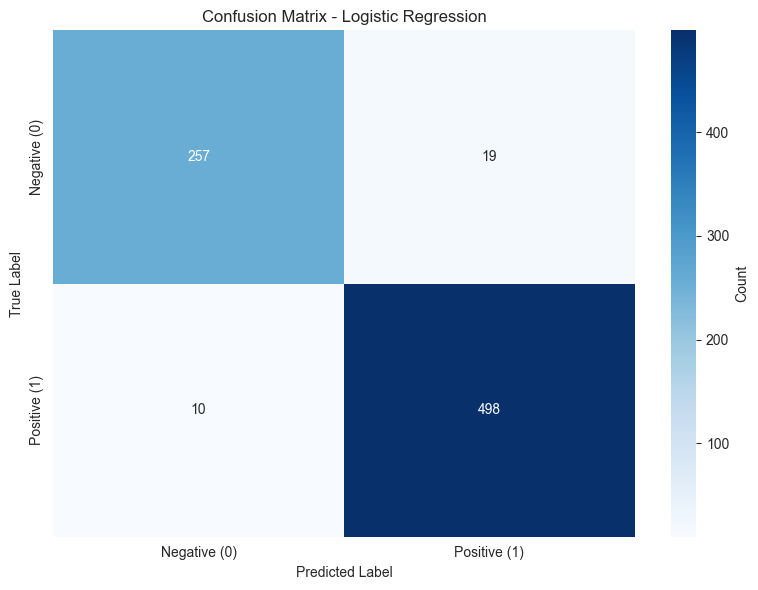

✅ 混淆矩阵已保存到 output/confusion_matrix.png


In [18]:
# 绘制混淆矩阵
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'],
            cbar_kws={'label': 'Count'},
            ax=ax)

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title(f'Confusion Matrix - {best_result["model_name"]}')

plt.tight_layout()
plt.savefig('../output/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ 混淆矩阵已保存到 output/confusion_matrix.png")

## 5. 总结和建议

### 模型性能排名
根据测试集准确率排序

### 关键发现
- 各模型的优缺点分析
- 特征类型的影响 (TF-IDF vs Count)
- 训练时间vs准确率的权衡

### 推荐方案
对于生产环境的模型选择建议

---

In [19]:
# 生成最终总结报告
print("\n" + "="*80)
print("📈 最终实验总结报告")
print("="*80)

# 按测试准确率排序
sorted_results = sorted(results, key=lambda x: x['test_accuracy'], reverse=True)

print(f"\n🏆 模型性能排名 (按测试集准确率):\n")
for i, result in enumerate(sorted_results, 1):
    print(f"{i}. {result['model_name']:20s} ({result['feature_type']:8s})")
    print(f"   - 测试准确率: {result['test_accuracy']:.4f} ({result['test_accuracy']*100:.2f}%)")
    print(f"   - 训练准确率: {result['train_accuracy']:.4f} ({result['train_accuracy']*100:.2f}%)")
    print(f"   - 训练时间: {result['training_time']:.4f}s")
    
    # 过拟合分析
    overfitting = result['train_accuracy'] - result['test_accuracy']
    if overfitting > 0.05:
        print(f"   ⚠️  过拟合程度: {overfitting*100:.2f}% (较高)")
    else:
        print(f"   ✅ 过拟合程度: {overfitting*100:.2f}% (正常)")
    print()

print("="*80)
print("\n💡 主要观察:\n")
print(f"• 最佳模型: {sorted_results[0]['model_name']} (准确率: {sorted_results[0]['test_accuracy']*100:.2f}%)")
print(f"• 最快的模型: {min(results, key=lambda x: x['training_time'])['model_name']} ({min([r['training_time'] for r in results]):.4f}s)")
print(f"• 最慢的模型: {max(results, key=lambda x: x['training_time'])['model_name']} ({max([r['training_time'] for r in results]):.4f}s)")

# 特征类型影响
tfidf_acc = [r['test_accuracy'] for r in results if r['feature_type'] == 'TF-IDF']
count_acc = [r['test_accuracy'] for r in results if r['feature_type'] == 'Count']

if tfidf_acc:
    print(f"\n• TF-IDF 特征平均准确率: {np.mean(tfidf_acc):.4f}")
if count_acc:
    print(f"• Count 特征平均准确率: {np.mean(count_acc):.4f}")

print("\n" + "="*80)


📈 最终实验总结报告

🏆 模型性能排名 (按测试集准确率):

1. Logistic Regression  (TF-IDF  )
   - 测试准确率: 0.9630 (96.30%)
   - 训练准确率: 0.9689 (96.89%)
   - 训练时间: 0.0462s
   ✅ 过拟合程度: 0.59% (正常)

2. Random Forest        (Count   )
   - 测试准确率: 0.9337 (93.37%)
   - 训练准确率: 0.9999 (99.99%)
   - 训练时间: 0.9036s
   ⚠️  过拟合程度: 6.62% (较高)

3. Naive Bayes          (Count   )
   - 测试准确率: 0.9209 (92.09%)
   - 训练准确率: 0.9407 (94.07%)
   - 训练时间: 0.0118s
   ✅ 过拟合程度: 1.98% (正常)

4. Decision Tree        (TF-IDF  )
   - 测试准确率: 0.9196 (91.96%)
   - 训练准确率: 0.9999 (99.99%)
   - 训练时间: 0.5691s
   ⚠️  过拟合程度: 8.02% (较高)

5. SVM                  (Count   )
   - 测试准确率: 0.6505 (65.05%)
   - 训练准确率: 0.6486 (64.86%)
   - 训练时间: 5.8576s
   ✅ 过拟合程度: -0.19% (正常)

6. KNN                  (TF-IDF  )
   - 测试准确率: 0.4311 (43.11%)
   - 训练准确率: 0.4639 (46.39%)
   - 训练时间: 1.8876s
   ✅ 过拟合程度: 3.28% (正常)


💡 主要观察:

• 最佳模型: Logistic Regression (准确率: 96.30%)
• 最快的模型: Naive Bayes (0.0118s)
• 最慢的模型: SVM (5.8576s)

• TF-IDF 特征平均准确率: 0.7713
• Count 特征平均准确率: 0.8350



In [20]:
# 将结果保存为CSV文件
results_summary = pd.DataFrame([
    {
        'Model': r['model_name'],
        'Feature Type': r['feature_type'],
        'Train Accuracy': r['train_accuracy'],
        'Test Accuracy': r['test_accuracy'],
        'Training Time (s)': r['training_time'],
        'Overfitting': r['train_accuracy'] - r['test_accuracy']
    }
    for r in sorted(results, key=lambda x: x['test_accuracy'], reverse=True)
])

results_summary.to_csv('../output/model_comparison_results.csv', index=False)
print("\n✅ 实验结果已保存到 output/model_comparison_results.csv")
print("\n最终结果摘要:")
print(results_summary.to_string(index=False))


✅ 实验结果已保存到 output/model_comparison_results.csv

最终结果摘要:
              Model Feature Type  Train Accuracy  Test Accuracy  Training Time (s)  Overfitting
Logistic Regression       TF-IDF        0.968923       0.963010           0.046211     0.005913
      Random Forest        Count        0.999858       0.933673           0.903595     0.066185
        Naive Bayes        Count        0.940684       0.920918           0.011819     0.019766
      Decision Tree       TF-IDF        0.999858       0.919643           0.569133     0.080215
                SVM        Count        0.648645       0.650510           5.857607    -0.001865
                KNN       TF-IDF        0.463885       0.431122           1.887588     0.032763


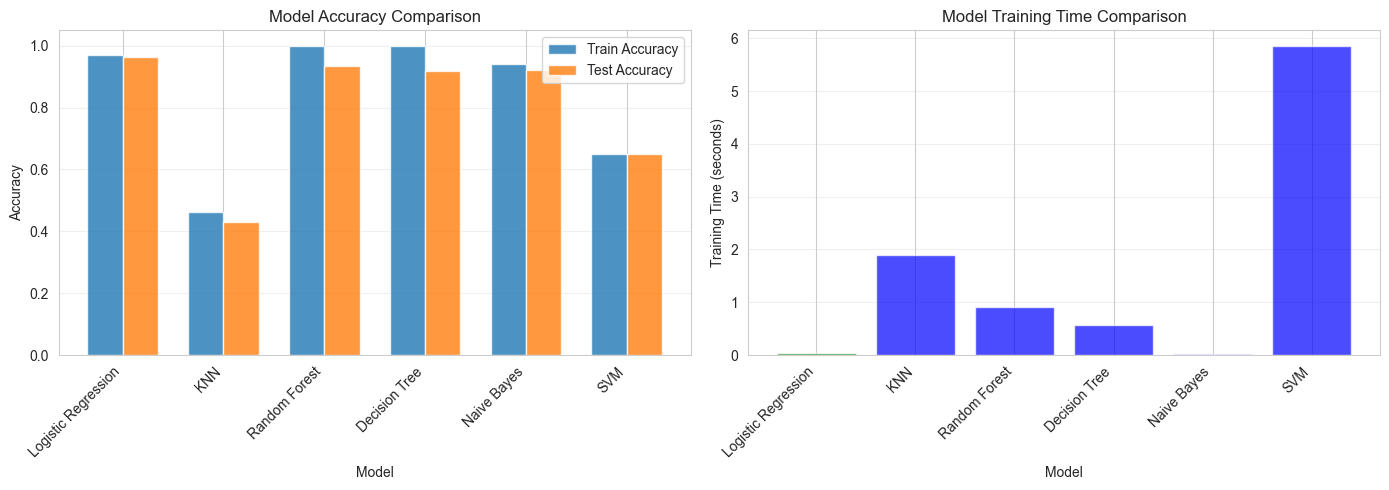

✅ 模型对比图已保存到 output/model_comparison.png


In [21]:
# 绘制准确率对比图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 准确率对比
model_names = [r['model_name'] for r in results]
test_accuracies = [r['test_accuracy'] for r in results]
train_accuracies = [r['train_accuracy'] for r in results]

x = np.arange(len(model_names))
width = 0.35

axes[0].bar(x - width/2, train_accuracies, width, label='Train Accuracy', alpha=0.8)
axes[0].bar(x + width/2, test_accuracies, width, label='Test Accuracy', alpha=0.8)
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# 训练时间对比
training_times = [r['training_time'] for r in results]
colors = ['green' if acc == max(test_accuracies) else 'blue' for acc in test_accuracies]

axes[1].bar(model_names, training_times, color=colors, alpha=0.7)
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Training Time (seconds)')
axes[1].set_title('Model Training Time Comparison')
axes[1].set_xticklabels(model_names, rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../output/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ 模型对比图已保存到 output/model_comparison.png")